In [18]:
import os
import time
import gc
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import VOCSegmentation, Cityscapes

import albumentations as A                      
#from torchvision import transforms

import cv2
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.segmentation import MeanIoU
from torchmetrics import JaccardIndex

import segmentation_models_pytorch as smp
from transformers import SegformerConfig, SegformerForSemanticSegmentation

from torch.amp import autocast, GradScaler

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches


In [ ]:
class Dataset_VOC(Dataset):

    def __init__(self, root, conjunto="train", transform=None):
        self.dataset = VOCSegmentation(
            root=root,
            year="2012",
            image_set=conjunto,
            download=True
        )
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, indice:int):
        image, mask = self.dataset[indice]

        image = np.array(image)
        mask = np.array(mask)

        

        if self.transform:
            t = self.transform(image=image,mask=mask)
            image = t["image"]
            mask = t["mask"].long()

        return image, mask

In [74]:
# Lista oficial de clases de Pascal VOC (índice = clase)
VOC_CLASES = [
    "background", "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable", "dog", "horse",
    "motorbike", "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]


def obtener_ejemplo_voc(root, indice=0, conjunto="train", guardar_path=None, mostrar=True):
    """
    Obtiene una imagen y su máscara del dataset Pascal VOC en tamaño original,
    sin transformaciones. Pensada para figuras de la memoria.
    
    Args:
        root: ruta raíz donde está VOCdevkit
        indice: índice de la imagen a extraer
        conjunto: "train" o "val"
        guardar_path: si se da, guarda la figura en esa ruta
        mostrar: si True, muestra la figura con plt.show()
    
    Returns:
        dict con la imagen, máscara y lista de clases presentes
    """
    
    # Cargar dataset sin transformaciones
    dataset = VOCSegmentation(
        root=root,
        year="2012",
        image_set=conjunto,
        download=False
    )
    
    image_pil, mask_pil = dataset[indice]
    
    image_np = np.array(image_pil)
    mask_np = np.array(mask_pil)
    
    # Identificar clases presentes (sin 255 que es void/ignore)
    clases_presentes = sorted([c for c in np.unique(mask_np).tolist() if c != 255])
    nombres_clases = [VOC_CLASES[c] for c in clases_presentes]
    
    # Colormap consistente: 21 clases + negro para 255
    base = plt.cm.tab20(np.linspace(0, 1, 20))
    extra = plt.cm.Set3(np.linspace(0, 1, 1))
    colores = np.vstack([base, extra])
    cmap = ListedColormap(colores)
    cmap.set_bad(color="black")
    
    # Enmascarar 255 para que se vea negro
    mask_plot = np.ma.masked_where(mask_np == 255, mask_np)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(image_np)
    axes[0].set_title(f"Imagen ({image_np.shape[1]}×{image_np.shape[0]})", fontsize=12)
    axes[0].axis("off")
    
    axes[1].imshow(mask_plot, cmap=cmap, vmin=0, vmax=20)
    axes[1].set_title("Máscara de segmentación", fontsize=12)
    axes[1].axis("off")
    
    # Leyenda con las clases presentes
    handles = [mpatches.Patch(color=cmap(c / 20), label=f"{c}: {VOC_CLASES[c]}")
               for c in clases_presentes]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(handles), 5),
               fontsize=10, bbox_to_anchor=(0.5, 0.10))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)
    
    if guardar_path:
        plt.savefig(guardar_path, dpi=200, bbox_inches="tight")
        print(f"Figura guardada en: {guardar_path}")
    
    if mostrar:
        plt.show()
    else:
        plt.close()
    
    return {
        "image": image_np,
        "mask": mask_np,
        "shape": image_np.shape,
        "clases": clases_presentes,
        "nombres_clases": nombres_clases
    }

Figura guardada en: ../memoria/benchmark1/ejemplo_voc1.png


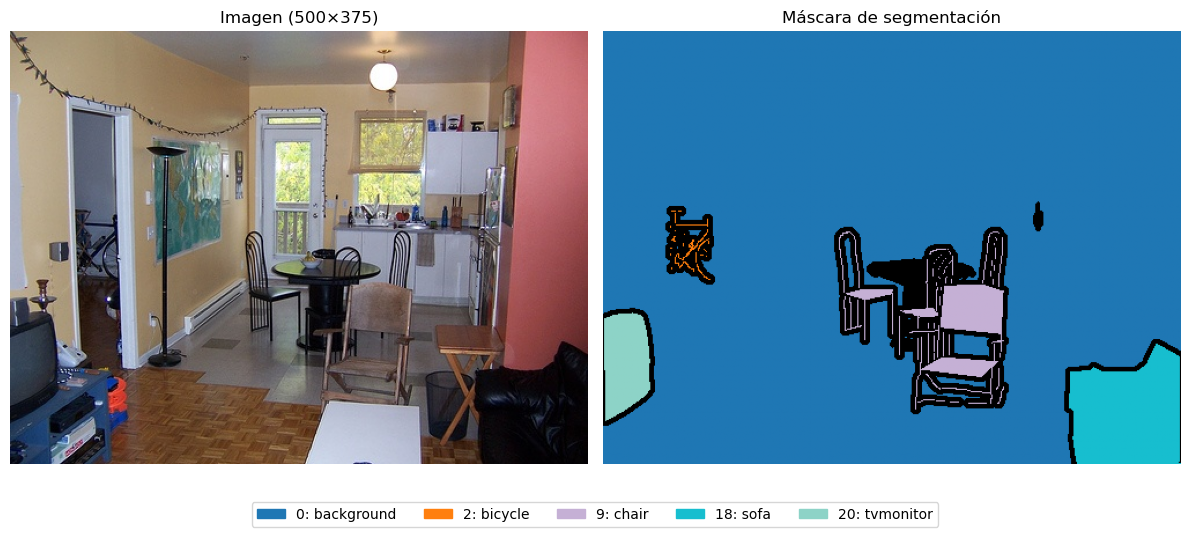

{'image': array([[[ 97,  89,  78],
         [159, 150, 135],
         [160, 145, 126],
         ...,
         [181,  90,  95],
         [181,  90,  95],
         [180,  89,  94]],
 
        [[ 82,  78,  66],
         [ 76,  68,  55],
         [146, 134, 120],
         ...,
         [184,  93,  98],
         [183,  92,  97],
         [183,  92,  97]],
 
        [[120, 123, 106],
         [ 41,  41,  29],
         [ 74,  64,  62],
         ...,
         [183,  94,  98],
         [182,  93,  97],
         [182,  93,  97]],
 
        ...,
 
        [[ 10,   9,  23],
         [  9,  11,  24],
         [  0,   2,  15],
         ...,
         [  3,   1,   4],
         [  3,   1,   4],
         [  3,   1,   4]],
 
        [[ 10,   9,  23],
         [  1,   3,  16],
         [ 19,  21,  34],
         ...,
         [  4,   2,   5],
         [  3,   1,   4],
         [  3,   1,   4]],
 
        [[  6,   8,  20],
         [ 15,  17,  29],
         [ 24,  26,  39],
         ...,
         [  4,   2,

In [75]:
obtener_ejemplo_voc(
    root="../data/",
    indice=32,
    conjunto="train",
    guardar_path="../memoria/benchmark1/ejemplo_voc1.png",
    mostrar=True
)

In [19]:
ID_TO_TRAINID = {
    -1: 255,   # license plate
    0: 255,  # unlabeled
    1: 255,  # ego vehicle
    2: 255,  # rectification border
    3: 255,  # out of roi
    4: 255,  # static
    5: 255,  # dynamic
    6: 255,  # ground
    7: 0,    # road
    8: 1,    # sidewalk
    9: 255,  # parking
    10: 255,  # rail track
    11: 2,    # building
    12: 3,    # wall
    13: 4,    # fence
    14: 255,  # guard rail
    15: 255,  # bridge
    16: 255,  # tunnel
    17: 5,    # pole
    18: 255,  # polegroup
    19: 6,    # traffic light
    20: 7,    # traffic sign
    21: 8,    # vegetation
    22: 9,    # terrain
    23: 10,   # sky
    24: 11,   # person
    25: 12,   # rider
    26: 13,   # car
    27: 14,   # truck
    28: 15,   # bus
    29: 255,  # caravan
    30: 255,  # trailer
    31: 16,   # train
    32: 17,   # motorcycle
    33: 18    # bicycle
}

In [20]:
LUT = np.full(34, 255, dtype=np.uint8)
for id_original, train_id in ID_TO_TRAINID.items():
    if id_original >= 0:
        LUT[id_original] = train_id


def convert_mask_id(mask):
    """Convierte máscara con IDs originales de Cityscapes a trainIds."""
    mask = np.asarray(mask, dtype=np.int32)
    
    mask = np.clip(mask, 0, 33)  # protege contra valores inesperados
    return LUT[mask]

In [21]:
class Dataset_Cityscape(Dataset):

    def __init__(self, conjunto="train", transform=None):
        self.dataset = Cityscapes(
            root="../data/cityscape",
            split=conjunto,
            mode="fine",
            target_type="semantic"
        )
        self.transform=transform

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, indice:int):
        image, mask = self.dataset[indice]

        image = np.array(image)
        mask = np.array(mask)

        mask = convert_mask_id(mask)
        mask = mask.astype(np.uint8)

        if self.transform:
            t = self.transform(image=image, mask=mask)
            image = t["image"]
            mask = t["mask"].long()
        return image, mask

In [80]:
# Lista de clases de Cityscapes en orden de trainId (0-18)
CITYSCAPES_CLASES = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation", "terrain",
    "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]


def obtener_ejemplo_cityscapes(root, indice=0, conjunto="train", guardar_path=None, mostrar=True):
    """
    Obtiene una imagen y su máscara del dataset Cityscapes en tamaño original,
    sin transformaciones de entrenamiento. Pensada para figuras de la memoria.
    
    Args:
        root: ruta raíz donde está la estructura de Cityscapes (con leftImg8bit y gtFine)
        indice: índice de la imagen a extraer
        conjunto: "train", "val" (test no tiene labels reales)
        guardar_path: si se da, guarda la figura en esa ruta
        mostrar: si True, muestra la figura con plt.show()
    
    Returns:
        dict con la imagen, máscara remapeada y lista de clases presentes
    """
    
    # Cargar dataset sin transformaciones
    dataset = Cityscapes(
        root=root,
        split=conjunto,
        mode="fine",
        target_type="semantic"
    )
    
    image_pil, mask_pil = dataset[indice]
    
    image_np = np.array(image_pil)
    mask_raw = np.array(mask_pil)
    
    # Remapear de IDs originales (0-33) a trainIds (0-18 + 255)
    mask_np = convert_mask_id(mask_raw)
    
    # Identificar clases presentes (sin 255 que es ignore)
    clases_presentes = sorted([c for c in np.unique(mask_np).tolist() if c != 255])
    nombres_clases = [CITYSCAPES_CLASES[c] for c in clases_presentes]
    
    # Colormap de 19 colores para Cityscapes
    colores = plt.cm.tab20(np.linspace(0, 1, 20))[:19]
    cmap = ListedColormap(colores)
    cmap.set_bad(color="black")
    
    # Enmascarar 255 para que se vea negro
    mask_plot = np.ma.masked_where(mask_np == 255, mask_np)
    
    # Plot — figsize más ancho porque Cityscapes es 2:1 panorámico
    fig, axes = plt.subplots(2, 1, figsize=(18, 10))
    
    axes[0].imshow(image_np)
    axes[0].set_title(f"Imagen ({image_np.shape[1]}×{image_np.shape[0]})", fontsize=12)
    axes[0].axis("off")
    
    axes[1].imshow(mask_plot, cmap=cmap, vmin=0, vmax=18)
    axes[1].set_title("Máscara de segmentación", fontsize=12)
    axes[1].axis("off")
    
    # Leyenda con las clases presentes
    handles = [mpatches.Patch(color=cmap(c / 18), label=f"{c}: {CITYSCAPES_CLASES[c]}")
               for c in clases_presentes]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(handles), 5),
               fontsize=11, bbox_to_anchor=(0.5, 0.10))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.20)
    
    if guardar_path:
        plt.savefig(guardar_path, dpi=200, bbox_inches="tight")
        print(f"Figura guardada en: {guardar_path}")
    
    if mostrar:
        plt.show()
    else:
        plt.close()
    
    return {
        "image": image_np,
        "mask": mask_np,
        "shape": image_np.shape,
        "clases": clases_presentes,
        "nombres_clases": nombres_clases
    }

Figura guardada en: ../memoria/benchmark2/ejemplo_cityscapes1.png


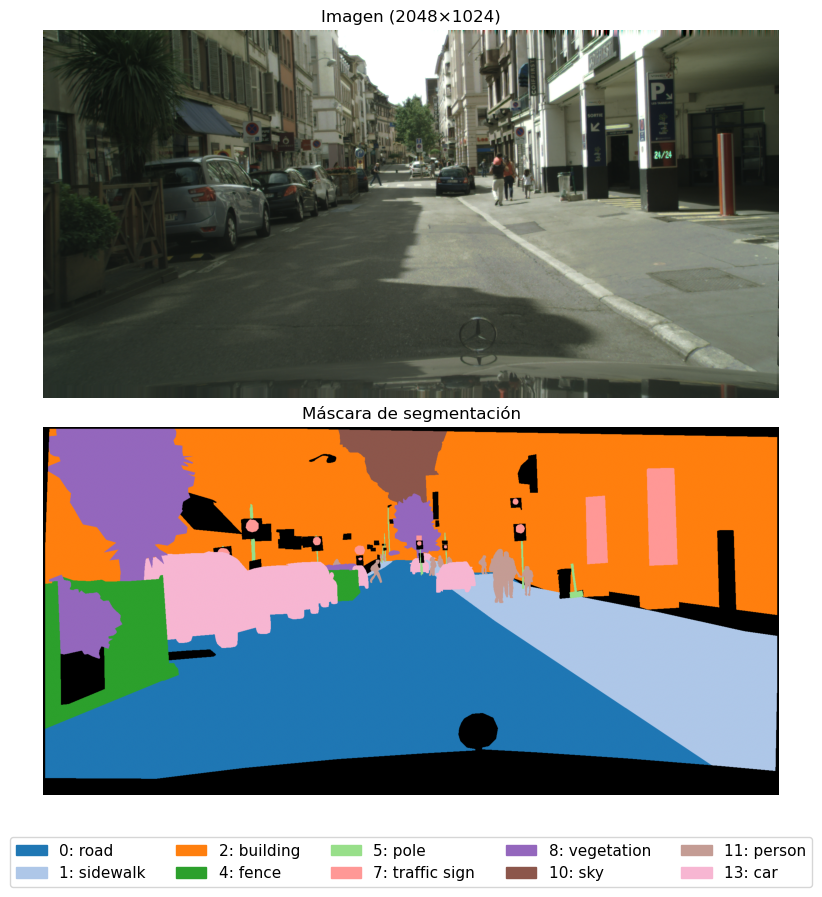

{'image': array([[[63, 73, 54],
         [63, 74, 54],
         [64, 74, 55],
         ...,
         [57, 86, 67],
         [26, 63, 40],
         [70, 69, 49]],
 
        [[68, 77, 56],
         [69, 77, 56],
         [69, 78, 57],
         ...,
         [57, 86, 67],
         [28, 63, 40],
         [71, 70, 49]],
 
        [[85, 92, 69],
         [83, 91, 68],
         [82, 90, 67],
         ...,
         [57, 85, 66],
         [31, 64, 41],
         [72, 70, 50]],
 
        ...,
 
        [[39, 47, 41],
         [39, 47, 40],
         [38, 46, 39],
         ...,
         [33, 39, 34],
         [33, 39, 34],
         [33, 39, 34]],
 
        [[39, 47, 41],
         [39, 47, 40],
         [38, 46, 39],
         ...,
         [34, 39, 34],
         [33, 39, 34],
         [33, 39, 34]],
 
        [[39, 47, 41],
         [39, 47, 40],
         [38, 46, 39],
         ...,
         [34, 39, 33],
         [34, 39, 33],
         [33, 39, 33]]], shape=(1024, 2048, 3), dtype=uint8),
 'mask': a

In [81]:
obtener_ejemplo_cityscapes(
    root="../data/cityscapes",
    indice=23,
    conjunto="train",
    guardar_path="../memoria/benchmark2/ejemplo_cityscapes1.png",
    mostrar=True
)